# Vector Error Correction Model (VECM) Analysis of Two Time Series

Recall that the VECM is given by,

$
\begin{align}
\Delta X_t &= A_1 X_{t-1} + \sum_{i=2}^n A_i \Delta X_{t - i + 1}  + \mathcal{E}_t
\end{align}
\tag{1}
$

where,

$
\begin{align}
\Delta X_t = \left[\Delta x_{1,t}, \Delta x_{2,t}\right]^\prime
\end{align}
\tag{2}
$

the $A_i$ are square $k\times k$ matrices and $\mathcal{E}_t$ is a serially uncorrelated random column
vector of length $k$ with distribution,

$
\begin{align}
\mathcal{E}_t \sim \text{Normal}(0,\Omega)
\end{align}
\tag{3}
$

Let $A_1 = \lambda\beta^\prime$ then cointegration requires,

$
\begin{align}
\text{rank}\left(\lambda \beta^\prime\right) = r < k
\end{align}
\tag{4}
$

where $\lambda$ has order $k\times r$ and $\beta^\prime$ has order $r\times k$.

## The Two Series Case

Here $k=2$, the smallest system that can cointegrate, and the case that matters for pairs trading.
The Johansen trace test walks the nulls $r \le 0$ and $r \le 1$ and reports one rank per significance
level (90%, 95% and 99%). The three possible ranks each mean something different,

| rank | meaning |
|------|---------|
| 0    | no cointegrating relation — the series share no common trend |
| 1    | one cointegrating relation — the pair is cointegrated and $\beta^\prime X_t$ is stationary |
| 2    | $\lambda\beta^\prime$ has full rank — both series are already stationary in levels |

Only rank 1 is the tradeable pairs case. For a single cointegrating vector the time asymptotic
relation,

$
\begin{align}
x_{1,t} - \beta_2 x_{2,t} = 0
\end{align}
\tag{5}
$

can be estimated with OLS, which provides an independent check on the Johansen $\beta$ estimate.

## Analysis Procedure

The steps to perform the analysis are as follows,

1. ADF stationarity test both series and difference the series until the tests pass. This number of
differences will define the integration order of the system. VECM models are $I(1)$ so should be
stationary after one difference.
2. Estimate model lags using `VAR.select_lag_order`. Verify with ACF-PACF.
3. After the first two steps it will be known that the series are $I(1)$ and the number of lags will
be known. `grangercausalitytests` can be applied to the first differences to determine the common
trend and suggest the model rank.
4. Use the Johansen test from `vecm.coint_johansen` to determine the rank of the model. This should
be consistent with the Granger causality results.
5. Now estimates for the rank and lag are known and the model parameters can be estimated using
`VECM.fit()`. OLS can be used to estimate the $\beta$ vector using the time asymptotic form.
6. Verify that the residual is stationary using the ADF test.

The simulations are seeded so that the reported estimates are reproducible.

In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import vecm, adf, stats, arima
from lib.plots import comparison, stack, twinx, comparison_stack, curve
from lib.data.impl.stats import OLS

# Config Plot Style
pyplot.style.use(config.glyfish_style)

In [2]:
def adf_test(xt):
    for i in range(len(xt)):
        result, _ = adf.compute_adf_test(xt[i])
        if result.status_vals[1]:
            print("Not Stationary")
        else:
            print("Stationary")

def plot_vecm_simulation(t, xt, title):
    labels = [r"$x_1$", r"$x_2$"]
    comparison(xt, t, labels=labels, title=title, xlabel=r"$t$", lw=1, title_offset=0.05)

def plot_vecm_dff(dxt, title):
    labels = [r"$\Delta x_1$", r"$\Delta x_2$"]
    stack(dxt, title=title, ylabels=labels, xlabel=r"$t$", lw=1, title_offset=0.05, figsize=(10, 6))

def pacf_acf_plot(t, dxt, nlags, title):
    acf = [stats.compute_acf(t, samp, nlags=nlags) for samp in dxt]
    pacf = [arima.compute_pacf(samp, nlags=nlags) for samp in dxt]
    data = [[acf[i][1], pacf[i][1]] for i in range(len(dxt))]
    time = [[acf[i][0], pacf[i][0]] for i in range(len(dxt))]
    comparison_stack(data, time, title=title, xlabel=r"Lag", ylim=(-0.25, 1.0), figsize=(10, 6),
                     labels=[["ACF", "PACF"]], ylabels=[r"$\Delta x_1$", r"$\Delta x_2$"])

## VECM(1) Two Series, One Cointegrating Vector

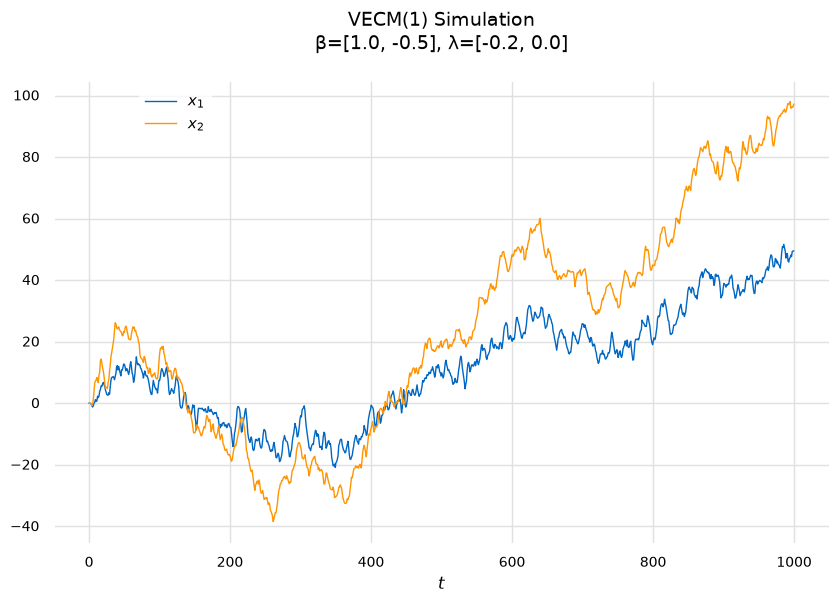

In [3]:
# seed the global RNG so the reported estimates are reproducible
numpy.random.seed(20260804)

λ = numpy.matrix([-0.2, 0.0]).T
β = numpy.matrix([1.0, -0.5])
a = numpy.matrix([[0.5, 0.0],
                  [0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0],
                  [0.0, 1.0]])

title = f"VECM(1) Simulation\nβ=[{β[0,0]}, {β[0,1]}], λ=[{λ[0,0]}, {λ[1,0]}]"
t, xt = vecm.create_vecm1_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [4]:
adf_test(xt)

Not Stationary
Not Stationary


In [5]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary


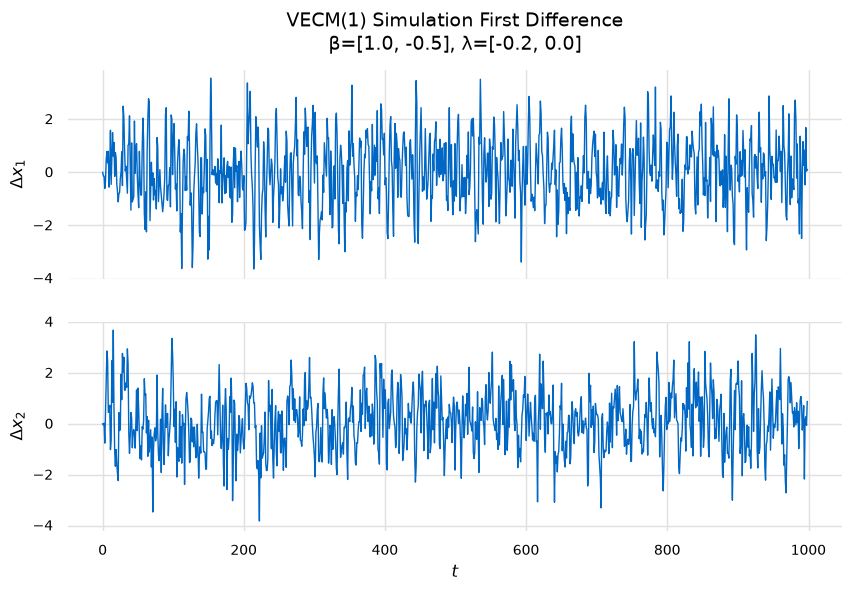

In [6]:
title = f"VECM(1) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}], λ=[{λ[0,0]}, {λ[1,0]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [7]:
result, result_model = vecm.compute_lag_order(xt, maxlags=4)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.6596,0.6991,1.934,0.6746
1,0.1190*,0.1781*,1.126*,0.1415*
2,0.1238,0.2027,1.132,0.1538
3,0.1290,0.2276,1.138,0.1665
4,0.1344,0.2527,1.144,0.1794


In [8]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "206be667-4323-4e13-b586-99ab8a183c6b",
   "_VAROrderTestReport__order": {
      "test_id": "206be667-4323-4e13-b586-99ab8a183c6b",
      "label": "$\\tau_{min}$",
      "value": 1
   },
   "_VAROrderTestReport__aic": {
      "test_id": "206be667-4323-4e13-b586-99ab8a183c6b",
      "order": {
         "test_id": "206be667-4323-4e13-b586-99ab8a183c6b",
         "label": "$\\tau_{AIC}$",
         "value": 1
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "206be667-4323-4e13-b586-99ab8a183c6b",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.11899705961679392
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "206be667-4323-4e13-b586-99ab8a183c6b",
      "order": {
         "test_id": "206be667-4323-4e13-b586-99ab8a183c6b",
         "label": "$\\tau_{BIC}$",
         "value": 1
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "206be667-4323-4e13-b586-99ab8a183c6b",
        

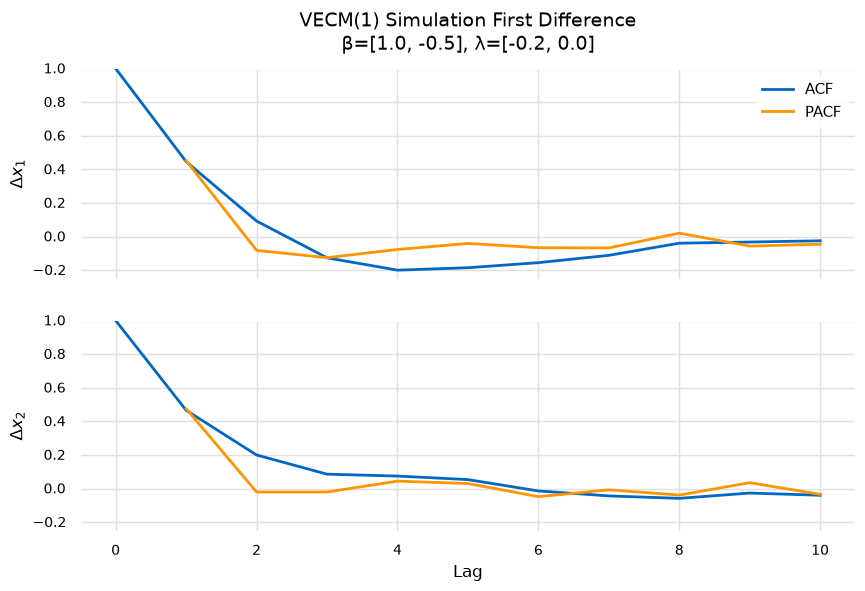

In [9]:
nlags = 10
title = f"VECM(1) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}], λ=[{λ[0,0]}, {λ[1,0]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [10]:
result, _ = arima.compute_ar_estimate(dxt[0], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1544.603
Date:                Sat, 29 Aug 2026   AIC                           3095.205
Time:                        16:02:29   BIC                           3109.926
Sample:                             0   HQIC                          3100.800
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0496      0.065      0.765      0.445      -0.077       0.177
ar.L1          0.4456      0.028     16.027      0.000       0.391       0.500
sigma2         1.2894      0.060     21.340      0.000       1.171       1.408
===================================================================================
Ljung-Box (L1) (Q):                   3.58   Jarque-Bera (JB):                 1.26
Prob(Q):                              0.06   Prob(JB):                         0.53
Heteroskedasticity (H):               0.92   Skew:                            -0.02
Prob(H) (two-sided):                  0.47   Kurtosis:                         2.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
result, _ = arima.compute_ar_estimate(dxt[1], order=1)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(1, 0, 0)   Log Likelihood               -1442.905
Date:                Sat, 29 Aug 2026   AIC                           2891.811
Time:                        16:03:13   BIC                           2906.531
Sample:                             0   HQIC                          2897.406
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0979      0.061      1.611      0.107      -0.021       0.217
ar.L1          0.4657      0.028     16.788      0.000       0.411       0.520
sigma2         1.0519      0.045     23.325      0.000       0.963       1.140
===================================================================================
Ljung-Box (L1) (Q):                   0.12   Jarque-Bera (JB):                 1.58
Prob(Q):                              0.73   Prob(JB):                         0.45
Heteroskedasticity (H):               0.97   Skew:                             0.03
Prob(H) (two-sided):                  0.76   Kurtosis:                         3.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [12]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=1)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=247.3117, p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=14.9898 , p=0.0001  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=15.0350 , p=0.0001  , df=1
likelihood ratio test: chi2=14.9229 , p=0.0001  , df=1
parameter F test:         F=14.9898 , p=0.0001  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=1.3330  , p=0.2486  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=1.3370  , p=0.2476  , df=1
likelihood ratio test: chi2=1.3361  , p=0.2477  , df=1
parameter F test:         F=1.3330  , p=0.2486  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  

In [13]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.0001,0.05,True,1,2
3,0.2486,0.05,False,2,1
4,1.0000,0.05,False,2,2


In [14]:
print(result_model.to_json(pretty=True))

{
   "test_id": "d239384c-7abb-4d1e-acb3-e3fa012dc13b",
   "rank": 1,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "d239384c-7abb-4d1e-acb3-e3fa012dc13b",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "d239384c-7abb-4d1e-acb3-e3fa012dc13b",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.0001,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": true
      },
      {
         "_GrangerCausalityTestResult__est_id": "d239384c-7abb-4d1e-acb3-e3fa012dc13b",
         "_GrangerCausalityTestResult__dep

### Johansen Test for Cointegration

For two series the trace test walks the nulls $r \le 0$ and $r \le 1$; the Rank table reports the
sequential-procedure rank at each significance level. The leading eigenvector, scaled by its first
component, is the cointegrating vector and should recover $\beta$.

The Johansen test over-rejects the $r \le 1$ null in finite samples — across seeds of this
simulation the true rank 1 is reported as 2 at the 90% level far more often than the nominal
10%, which is why the rank is read from the stricter significance levels.

In [15]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 1)

In [17]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          199.748 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │            0.054 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════════╛

Rank
╒══════════════════════╤══════════════════════╤══════════════════════╕
│   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞══════════════════════╪══════════════════════╪═══════════════════

In [18]:
print(result_model.to_json(pretty=True))

{
   "test_id": "77d79039-0a91-47bc-ac36-262094a064e6",
   "trace_test": [
      {
         "test_id": "77d79039-0a91-47bc-ac36-262094a064e6",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 199.74779743061774,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "test_result": [
            true,
            true,
            true
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ]
      },
      {
         "test_id": "77d79039-0a91-47bc-ac36-262094a064e6",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 0.0541789267881477,
         "critical_values": [
            2.7055,
            3.8415,
            6.6349
         ],
         "test_result": [
            false,
            false,
            false
         ],
         "significance_levels": [
    

### VECM Parameter Estimation

```
λ = numpy.matrix([-0.2, 0.0]).T
β = numpy.matrix([1.0, -0.5])
a = numpy.matrix([[0.5, 0.0],
                  [0.0, 0.5]])
Ω = numpy.matrix([[1.0, 0.0],
                  [0.0, 1.0]])
```


In [19]:
result, result_model = vecm.compute_estimate(xt, maxlags=1, rank=1)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0143,0.032,-0.441,0.659,-0.078,0.049
L1.y1,0.5029,0.026,19.341,0.000,0.452,0.554
L1.y2,-0.0173,0.030,-0.586,0.558,-0.075,0.041
,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0521,0.033,1.595,0.111,-0.012,0.116
L1.y1,0.0279,0.026,1.067,0.286,-0.023,0.079
L1.y2,0.4665,0.030,15.737,0.000,0.408,0.525
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,-0.1964,0.013,-14.843,0.000,-0.222,-0.170
,coef,std err,z,P>|z|,[0.025,0.975]


In [20]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 1,
   "const": [
      {
         "est": -0.014337473787347732,
         "err": 0.03249960877504654,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "5ddd0d8d-7d18-4074-9c9d-150170e4aceb",
         "param_type": "VECM_CONST"
      },
      {
         "est": 0.0520841345157843,
         "err": 0.03265094854093183,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "5ddd0d8d-7d18-4074-9c9d-150170e4aceb",
         "param_type": "VECM_CONST"
      }
   ],
   "order": 1,
   "lambda_est": [
      {
         "est": -0.19635494460786326,
         "err": 0.013228904954432909,
         "est_label": "$\\hat{\\lambda}$",
         "err_label": "$\\sigma_{\\lambda}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "5ddd0

In [21]:
beta_est = result.beta
beta_est

array([[ 1.        ],
       [-0.50175549]])

### Cointegration Vector Estimation using OLS on Time Asymptotic Relationships

```
β = numpy.matrix([1.0, -0.5])
```

In [22]:
result, result_model = OLS.LINEAR.multi_variable_estimate(xt[0], xt[1:])
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                 4.647e+04
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        16:13:13   Log-Likelihood:                -2371.1
No. Observations:                1000   AIC:                             4746.
Df Residuals:                     998   BIC:                             4756.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1231      0.099     -1.237      0.216      -0.318       0.072
x1             0.4983      0.002    215.570      0.000       0.494       0.503
==============================================================================
Omnibus:                        8.279   Durbin-Watson:                   0.266
Prob(Omnibus):                  0.016   Jarque-Bera (JB):                5.899
Skew:                           0.040   Prob(JB):                       0.0524
Kurtosis:                       2.632   Cond. No.                         52.2
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [22]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.12307207526569947,
      "err": 0.09948624389558194,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "d9bd547b-4c14-447a-bc37-c754043848a3",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.4983422624930812,
         "err": 0.0023117433867655642,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "d9bd547b-4c14-447a-bc37-c754043848a3",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9789754764520442,
   "param_transforms": null,
   "const_transform": null,
   "est_id": "d9bd547b-4c14-447a-bc37-c754043848a3",
   "model": null
}


### Verify Error Correction term Residual Stationarity

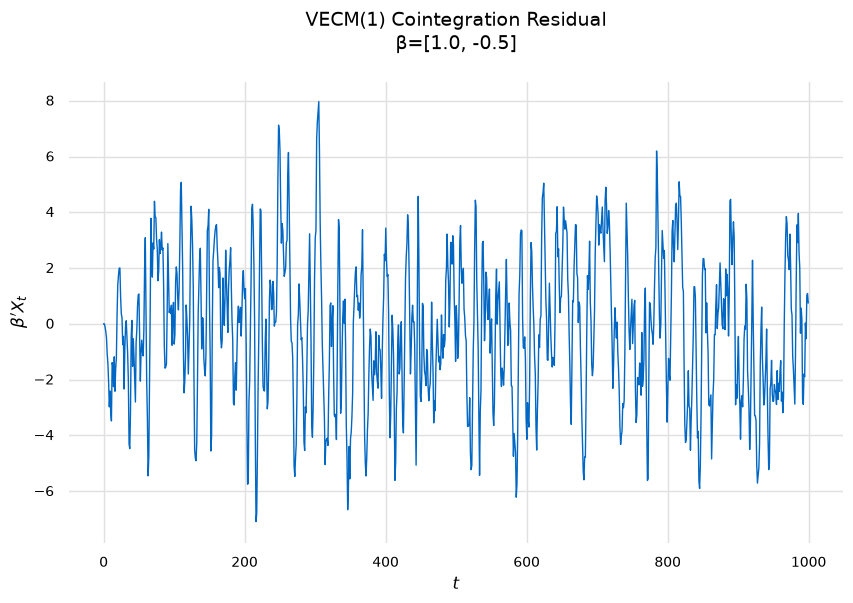

In [23]:
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(1) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [24]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -13.8676      │
├────────────────┼───────────────┤
│ pvalue         │   4.26574e-25 │
├────────────────┼───────────────┤
│ Lags           │   1           │
├────────────────┼───────────────┤
│ Number Obs     │ 998           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛


## VECM(2) Two Series, One Cointegrating Vector

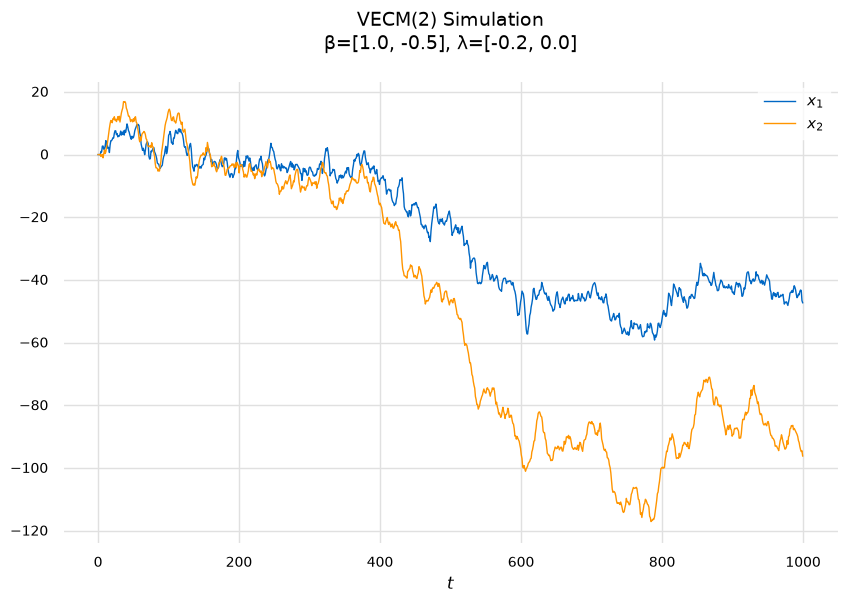

In [25]:
# seed the global RNG so the reported estimates are reproducible
numpy.random.seed(20260801)

λ = numpy.matrix([-0.2, 0.0]).T
β = numpy.matrix([1.0, -0.5])
a = numpy.array([[[0.25, 0.0],
                  [0.0, 0.25]],
                 [[0.25, 0.0],
                  [0.0, 0.25]]])
Ω = numpy.matrix([[1.0, 0.0],
                  [0.0, 1.0]])

title = f"VECM(2) Simulation\nβ=[{β[0,0]}, {β[0,1]}], λ=[{λ[0,0]}, {λ[1,0]}]"
t, xt = vecm.create_vecm_source(λ, β, a, Ω=Ω)
plot_vecm_simulation(t, xt, title)

### Stationarity Test

In [26]:
adf_test(xt)

Not Stationary


Not Stationary


In [27]:
dt, dxt = stats.compute_diff(t, xt)
adf_test(dxt)

Stationary
Stationary


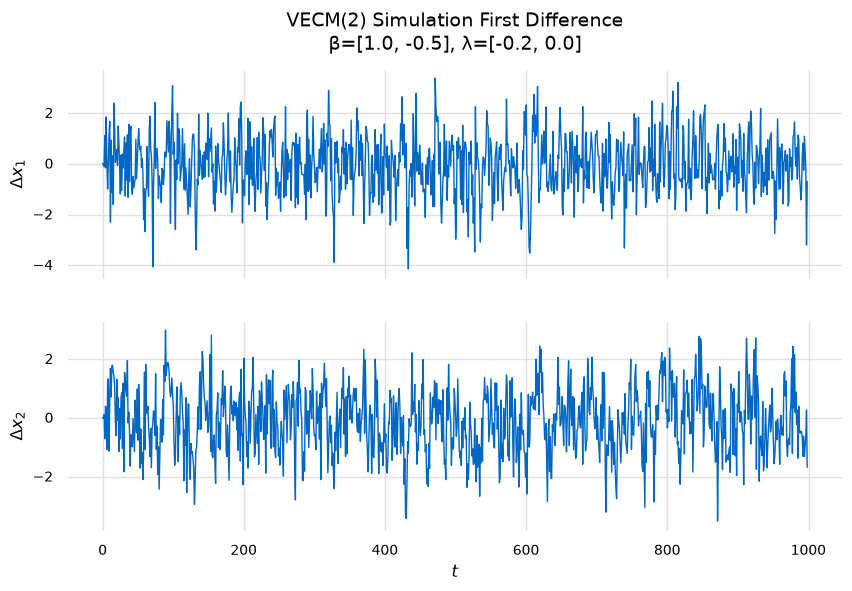

In [28]:
title = f"VECM(2) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}], λ=[{λ[0,0]}, {λ[1,0]}]"
plot_vecm_dff(dxt, title)

### Order Determination

In [29]:
result, result_model = vecm.compute_lag_order(xt, maxlags=6)
result.summary()

,AIC,BIC,FPE,HQIC
0,0.3590,0.3985,1.432,0.3740
1,0.1362,0.1954,1.146,0.1587
2,0.04828*,0.1272*,1.049*,0.07830*
3,0.04956,0.1483,1.051,0.08709
4,0.05381,0.1723,1.055,0.09884
5,0.05881,0.1970,1.061,0.1114
6,0.06408,0.2220,1.066,0.1241


In [30]:
print(result_model.to_json(pretty=True))

{
   "_VAROrderTestReport__test_id": "2b9b1be5-95bc-4576-b7b5-5ab63c1b97d8",
   "_VAROrderTestReport__order": {
      "test_id": "2b9b1be5-95bc-4576-b7b5-5ab63c1b97d8",
      "label": "$\\tau_{min}$",
      "value": 2
   },
   "_VAROrderTestReport__aic": {
      "test_id": "2b9b1be5-95bc-4576-b7b5-5ab63c1b97d8",
      "order": {
         "test_id": "2b9b1be5-95bc-4576-b7b5-5ab63c1b97d8",
         "label": "$\\tau_{AIC}$",
         "value": 2
      },
      "error_metric": "AIC",
      "value": {
         "test_id": "2b9b1be5-95bc-4576-b7b5-5ab63c1b97d8",
         "label": "$\\varepsilon_{AIC}$",
         "value": 0.04827898909834751
      }
   },
   "_VAROrderTestReport__bic": {
      "test_id": "2b9b1be5-95bc-4576-b7b5-5ab63c1b97d8",
      "order": {
         "test_id": "2b9b1be5-95bc-4576-b7b5-5ab63c1b97d8",
         "label": "$\\tau_{BIC}$",
         "value": 2
      },
      "error_metric": "BIC",
      "value": {
         "test_id": "2b9b1be5-95bc-4576-b7b5-5ab63c1b97d8",
        

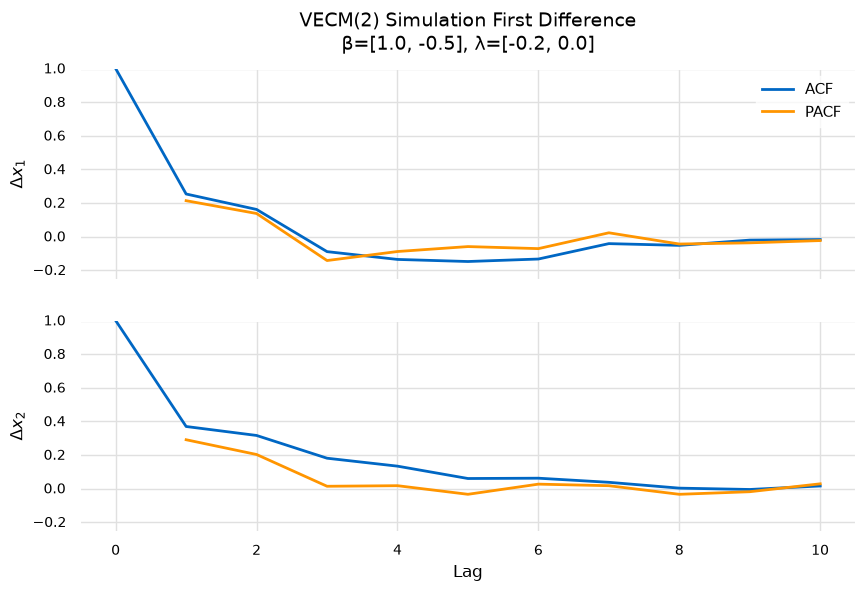

In [31]:
nlags = 10
title = f"VECM(2) Simulation First Difference\nβ=[{β[0,0]}, {β[0,1]}], λ=[{λ[0,0]}, {λ[1,0]}]"
pacf_acf_plot(dt, dxt, 10, title)

### $\Delta X_t$ Parameter Estimation

In [32]:
result, _ = arima.compute_ar_estimate(dxt[0], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1525.151
Date:                Sat, 29 Aug 2026   AIC                           3058.301
Time:                        15:51:14   BIC                           3077.928
Sample:                             0   HQIC                          3065.761
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0481      0.053     -0.909      0.363      -0.152       0.056
ar.L1          0.2267      0.030      7.598      0.000       0.168       0.285
ar.L2          0.1048      0.032      3.277      0.001       0.042       0.167
sigma2         1.2403      0.054     22.845      0.000       1.134       1.347
===================================================================================
Ljung-Box (L1) (Q):                   0.31   Jarque-Bera (JB):                 2.78
Prob(Q):                              0.58   Prob(JB):                         0.25
Heteroskedasticity (H):               0.88   Skew:                            -0.12
Prob(H) (two-sided):                  0.23   Kurtosis:                         3.11
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [33]:
result, _ = arima.compute_ar_estimate(dxt[1], order=2)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  999
Model:                 ARIMA(2, 0, 0)   Log Likelihood               -1429.217
Date:                Sat, 29 Aug 2026   AIC                           2866.435
Time:                        15:51:15   BIC                           2886.062
Sample:                             0   HQIC                          2873.895
                                - 999                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0976      0.064     -1.518      0.129      -0.224       0.028
ar.L1          0.2928      0.029      9.983      0.000       0.235       0.350
ar.L2          0.2076      0.030      6.996      0.000       0.149       0.266
sigma2         1.0234      0.050     20.321      0.000       0.925       1.122
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 4.75
Prob(Q):                              0.94   Prob(JB):                         0.09
Heteroskedasticity (H):               1.00   Skew:                            -0.04
Prob(H) (two-sided):                  0.98   Kurtosis:                         2.67
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Granger Causality

In [34]:
result, result_model = stats.compute_causality_matrix(dxt, nlags=2)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.0000  , p=1.0000  , df_denom=996, df_num=1
ssr based chi2 test:   chi2=0.0000  , p=1.0000  , df=1
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=1
parameter F test:         F=68.3219 , p=0.0000  , df_denom=996, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=-0.0000 , p=1.0000  , df_denom=994, df_num=2
ssr based chi2 test:   chi2=-0.0000 , p=1.0000  , df=2
likelihood ratio test: chi2=-0.0000 , p=1.0000  , df=2
parameter F test:         F=39.9690 , p=0.0000  , df_denom=994, df_num=2

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=18.0580 , p=0.0000  , df_denom=995, df_num=1
ssr based chi2 test:   chi2=18.1124 , p=0.0000  , df=1
likelihood ratio test: chi2=17.9500 , p=0.0000  , df=1
parameter F test:         F=18.0580 , p=0.0000  , df_denom=995, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=26.3255 , p=0.0000  

In [35]:
result.head(10)

,pvalue,critical_value,result,dependent_var,causal_var
1,1.0000,0.05,False,1,1
2,0.0000,0.05,True,1,2
3,0.7186,0.05,False,2,1
4,1.0000,0.05,False,2,2


In [36]:
print(result_model.to_json(pretty=True))

{
   "test_id": "56879404-b89b-4d71-ac49-ac6a79085cc9",
   "rank": 1,
   "results": [
      {
         "_GrangerCausalityTestResult__est_id": "56879404-b89b-4d71-ac49-ac6a79085cc9",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 1,
         "_GrangerCausalityTestResult__pvalue": 1.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": false
      },
      {
         "_GrangerCausalityTestResult__est_id": "56879404-b89b-4d71-ac49-ac6a79085cc9",
         "_GrangerCausalityTestResult__dependent_var": 1,
         "_GrangerCausalityTestResult__causal_var": 2,
         "_GrangerCausalityTestResult__pvalue": 0.0,
         "_GrangerCausalityTestResult__critical_value": 0.05,
         "_GrangerCausalityTestResult__result": true
      },
      {
         "_GrangerCausalityTestResult__est_id": "56879404-b89b-4d71-ac49-ac6a79085cc9",
         "_GrangerCausalityTestResult__depend

### Johansen Test for Cointegration

For two series the trace test walks the nulls $r \le 0$ and $r \le 1$; the Rank table reports the
sequential-procedure rank at each significance level. The leading eigenvector, scaled by its first
component, is the cointegrating vector and should recover $\beta$.

The Johansen test over-rejects the $r \le 1$ null in finite samples — across seeds of this
simulation the true rank 1 is reported as 2 at the 90% level far more often than the nominal
10%, which is why the rank is read from the stricter significance levels.

In [37]:
result, result_model, _ = vecm.compute_johansen_coint_test(xt, 2)

In [38]:
result.summary()

Trace Statistic
╒═══════════════════╤══════════════════╤══════════════════════╤══════════════════════╤══════════════════════╕
│ Null Hypothesis   │   Test Statistic │   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞═══════════════════╪══════════════════╪══════════════════════╪══════════════════════╪══════════════════════╡
│ r <= 0            │          175.484 │               13.429 │               15.494 │               19.935 │
├───────────────────┼──────────────────┼──────────────────────┼──────────────────────┼──────────────────────┤
│ r <= 1            │            0.553 │                2.705 │                3.841 │                6.635 │
╘═══════════════════╧══════════════════╧══════════════════════╧══════════════════════╧══════════════════════╛

Rank
╒══════════════════════╤══════════════════════╤══════════════════════╕
│   Critical Value 90% │   Critical Value 95% │   Critical Value 99% │
╞══════════════════════╪══════════════════════╪═══════════════════

In [39]:
print(result_model.to_json(pretty=True))

{
   "test_id": "ff85d1b0-976f-4116-a118-af8ef7b00922",
   "trace_test": [
      {
         "test_id": "ff85d1b0-976f-4116-a118-af8ef7b00922",
         "test_rank": 0,
         "null_hypothesis": "r<=0",
         "test_stat": 175.48427380017688,
         "critical_values": [
            13.4294,
            15.4943,
            19.9349
         ],
         "test_result": [
            true,
            true,
            true
         ],
         "significance_levels": [
            "Critical Value 90%",
            "Critical Value 95%",
            "Critical Value 99%"
         ]
      },
      {
         "test_id": "ff85d1b0-976f-4116-a118-af8ef7b00922",
         "test_rank": 1,
         "null_hypothesis": "r<=1",
         "test_stat": 0.5527592052225005,
         "critical_values": [
            2.7055,
            3.8415,
            6.6349
         ],
         "test_result": [
            false,
            false,
            false
         ],
         "significance_levels": [
    

### VECM Parameter Estimation

```
λ = numpy.matrix([-0.2, 0.0]).T
β = numpy.matrix([1.0, -0.5])
a = numpy.array([[[0.25, 0.0],
                  [0.0, 0.25]],
                 [[0.25, 0.0],
                  [0.0, 0.25]]])
Ω = numpy.matrix([[1.0, 0.0],
                  [0.0, 1.0]])
```


In [40]:
result, result_model = vecm.compute_estimate(xt, maxlags=2, rank=1)
result.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
const,0.0072,0.032,0.226,0.821,-0.055,0.069
L1.y1,0.2514,0.029,8.762,0.000,0.195,0.308
L1.y2,-0.0564,0.032,-1.778,0.075,-0.119,0.006
L2.y1,0.2007,0.029,6.840,0.000,0.143,0.258
L2.y2,0.0518,0.033,1.591,0.112,-0.012,0.116
,coef,std err,z,P>|z|,[0.025,0.975]
const,-0.0511,0.032,-1.585,0.113,-0.114,0.012
L1.y1,-0.0221,0.029,-0.758,0.448,-0.079,0.035
L1.y2,0.3033,0.032,9.406,0.000,0.240,0.366
L2.y1,-0.0193,0.030,-0.649,0.516,-0.078,0.039


In [41]:
print(result_model.to_json(pretty=True))

{
   "est_model": "VECM",
   "rank": 1,
   "const": [
      {
         "est": 0.007184374658546401,
         "err": 0.031747560664137545,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "5fda2e10-a68f-4f72-9cd1-06c3c0c89afd",
         "param_type": "VECM_CONST"
      },
      {
         "est": -0.051121826950658644,
         "err": 0.03225498900125647,
         "est_label": "$\\hat{M}$",
         "err_label": "$\\sigma_{M}$",
         "row": 1,
         "column": 0,
         "order": 0,
         "est_id": "5fda2e10-a68f-4f72-9cd1-06c3c0c89afd",
         "param_type": "VECM_CONST"
      }
   ],
   "order": 2,
   "lambda_est": [
      {
         "est": -0.22204255778481238,
         "err": 0.01612777264240563,
         "est_label": "$\\hat{\\lambda}$",
         "err_label": "$\\sigma_{\\lambda}$",
         "row": 0,
         "column": 0,
         "order": 0,
         "est_id": "5fd

In [42]:
beta_est = result.beta
beta_est

array([[ 1.        ],
       [-0.49964668]])

### Cointegration Vector Estimation using OLS on Time Asymptotic Relationships

```
β = numpy.matrix([1.0, -0.5])
```

In [43]:
result, result_model = OLS.LINEAR.multi_variable_estimate(xt[0], xt[1:])
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.988
Model:                            OLS   Adj. R-squared:                  0.988
Method:                 Least Squares   F-statistic:                 8.420e+04
Date:                Sat, 29 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:51:15   Log-Likelihood:                -2253.0
No. Observations:                1000   AIC:                             4510.
Df Residuals:                     998   BIC:                             4520.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.1123      0.111      1.010      0.313      -0.106       0.331
x1             0.4988      0.002    290.173      0.000       0.495       0.502
==============================================================================
Omnibus:                        6.161   Durbin-Watson:                   0.289
Prob(Omnibus):                  0.046   Jarque-Bera (JB):                7.565
Skew:                           0.066   Prob(JB):                       0.0228
Kurtosis:                       3.405   Cond. No.                         98.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [44]:
print(result_model.to_json(pretty=True))

{
   "est_model": "OLS",
   "const": {
      "est": 0.11228954989085427,
      "err": 0.11120211177079106,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "5570fa98-6268-43fe-af23-61727e1fb3a8",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": 0.4987542759615619,
         "err": 0.0017188164721157998,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "5570fa98-6268-43fe-af23-61727e1fb3a8",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": 0.9882861675394001,
   "param_transforms": null,
   "const_transform": null,
   "est_id": "5570fa98-6268-43fe-af23-61727e1fb3a8",
   "model": null
}


### Verify Error Correction term Residual Stationarity

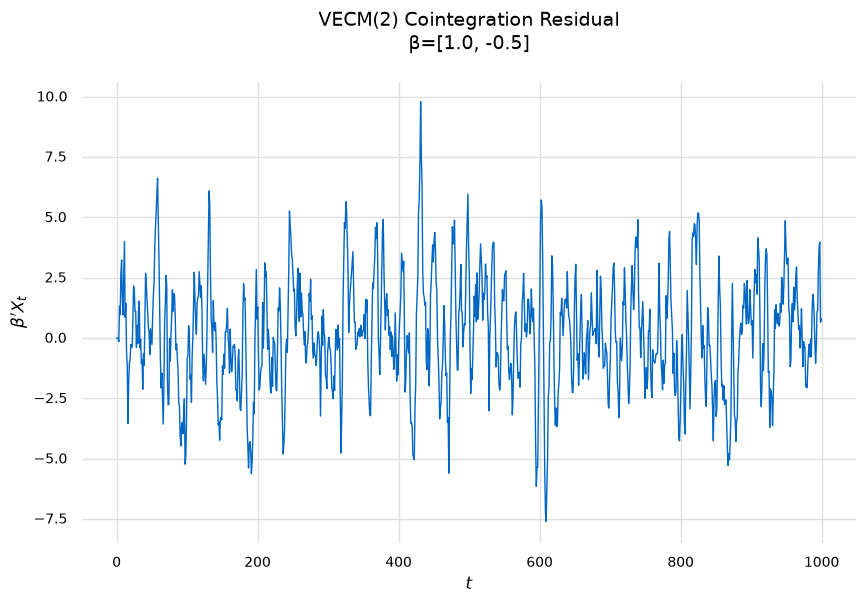

In [45]:
coint = beta_est.T[0] * xt.T / beta_est.T[0][0]
residual = numpy.sum(coint, axis=1)

title = f"VECM(2) Cointegration Residual\nβ=[{β[0,0]}, {β[0,1]}]"
curve(residual, title=title, xlabel=r"$t$", ylabel=r"$\beta^\prime X_t$", lw=1, title_offset=0.05)

In [24]:
result, _ = adf.compute_adf_test(residual)
result.summary()

╒════════════════╤═══════════════╕
│ Test Statistic │ -13.8676      │
├────────────────┼───────────────┤
│ pvalue         │   4.26574e-25 │
├────────────────┼───────────────┤
│ Lags           │   1           │
├────────────────┼───────────────┤
│ Number Obs     │ 998           │
╘════════════════╧═══════════════╛
╒════════════════╤══════════════════╤══════════╕
│ Significance   │   Critical Value │ Result   │
╞════════════════╪══════════════════╪══════════╡
│ 1%             │         -2.56798 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 5%             │         -1.94127 │ Failed   │
├────────────────┼──────────────────┼──────────┤
│ 10%            │         -1.61656 │ Failed   │
╘════════════════╧══════════════════╧══════════╛
